# 1 First Try to HandMade model

In [2]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(60000,)


# 1.1 Import and data
I import all the the things and data I need to build and train my model and I separate it to have my train and test data.
I also verified they are in good dimensions

In [3]:
def FullyConnectedLayer(W, x, b):
  j = W @ x + b
  return j

def ReLULayer(x):
 x = np.maximum(0, x)
 return x

def softmax(x):
 exp_x = np.exp(x - np.max(x))
 sum_exp_x = np.sum(exp_x)
 softmax_x = exp_x / sum_exp_x
 return softmax_x

def Loss(y_pred, y):
  v = y_pred[y]
  result = -np.log(v)
  return(result)

W_FCLayer3 = np.random.randn(128, 784)* 0.01
W_FCLayer2 = np.random.randn(64, 128)* 0.01
W_FCLayer1 = np.random.randn(10, 64)* 0.01

b_FCLayer3 = np.zeros((128, 1))
b_FCLayer2 = np.zeros((64, 1))
b_FCLayer1 = np.zeros((10, 1))

LayerProduction = {
}
LossStock = []

# 1.2 Define Function and weight

I create all the types of layers I need for the model (fully-connected, ReLU, softmax), and initialize my 3 layers' parameters — random values for the weights, zeros for the biases.

I also create LayerProduction, a dictionary used to cache the forward pass values (needed later to compute gradients), the Loss function to evaluate the model's error, and LossStock, a list to track the loss over training iterations.

In [4]:
def Gradient_1(y, y_pred):
 d = np.zeros((10, 1))
 d[y] = 1
 gradient1 = y_pred - d
 return(gradient1)

def Gradient2(a, gradient1):
  gradient2_W = gradient1 @ a.T
  gradient2_b = gradient1.copy()
  return(gradient2_W, gradient2_b)

def Gradient3(z, gradient1, W):
  delta_prev = (W.T @ gradient1) * (z > 0)
  return(delta_prev)

def Gradient4(a, delta_prev):
  gradient3_W = delta_prev @ a.T
  gradient3_b = delta_prev.copy()
  return(gradient3_W, gradient3_b)

def Gradient5(z, delta_prev, W):
  delta_prev2 = (W.T @ delta_prev) * (z > 0)
  return(delta_prev2)

def Gradient6(a, delta_prev2):
  gradient4_W = delta_prev2 @ a.T
  gradient4_b = delta_prev2.copy()
  return(gradient4_W, gradient4_b)

def maj_W(gradient_W, W, n):
  W = W - n*gradient_W
  return(W)

def maj_b(gradient_b, b, n):
  b = b - n*gradient_b
  return(b)


# 1.3 Creation of Backpropagation
I define all the functions needed for backpropagation: one gradient function per layer (following the chain rule, in reverse order from output to input), plus the update functions (maj_W, maj_b) that apply gradient descent to adjust the parameters.

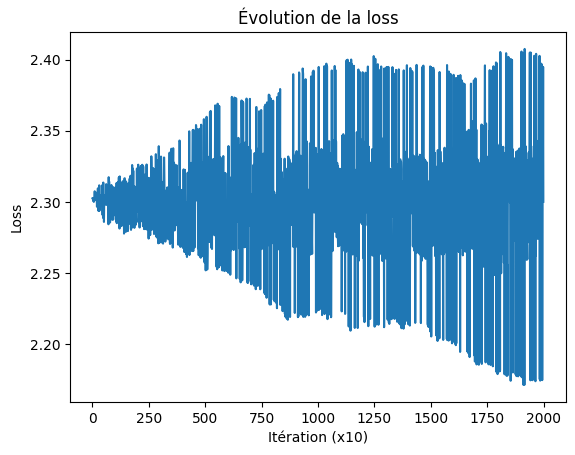

In [5]:
for i in range(20000):
  x = X_train[i].reshape(784, 1) / 255
  y = y_train[i]
  LayerProduction["x"] = x.copy()
  FC3 = FullyConnectedLayer(W_FCLayer3, x, b_FCLayer3)
  LayerProduction["FC3_Result"] = FC3.copy()
  ReLU2 = ReLULayer(FC3)
  LayerProduction["ReLU2_Result"] = ReLU2.copy()
  FC2 = FullyConnectedLayer(W_FCLayer2, ReLU2, b_FCLayer2)
  LayerProduction["FC2_Result"] = FC2.copy()
  ReLU1 = ReLULayer(FC2)
  LayerProduction["ReLU1_Result"] = ReLU1.copy()
  FC1 = FullyConnectedLayer(W_FCLayer1, ReLU1, b_FCLayer1)
  LayerProduction["FC1_Result"] = FC1.copy()
  Soft = softmax(FC1)
  y_pred = Soft


  Gra1 = Gradient_1(y, y_pred)
  Gra2 = Gradient2(ReLU1, Gra1)
  Gra3 = Gradient3(FC2, Gra1, W_FCLayer1)
  Gra4 = Gradient4(ReLU2, Gra3)
  Gra5 = Gradient5(FC3, Gra3, W_FCLayer2)
  Gra6 = Gradient6(x, Gra5)

  maj_b_FC3 = maj_b(Gra6[1],b_FCLayer3, 0.001)
  maj_W_FC3 = maj_W(Gra6[0],W_FCLayer3, 0.001)

  maj_b_FC2 = maj_b(Gra4[1],b_FCLayer2, 0.001)
  maj_W_FC2 = maj_W(Gra4[0],W_FCLayer2, 0.001)

  maj_b_FC1 = maj_b(Gra2[1],b_FCLayer1, 0.001)
  maj_W_FC1 = maj_W(Gra2[0],W_FCLayer1, 0.001)

  b_FCLayer3 = maj_b_FC3
  W_FCLayer3 = maj_W_FC3
  b_FCLayer2 = maj_b_FC2
  W_FCLayer2 = maj_W_FC2
  b_FCLayer1 = maj_b_FC1
  W_FCLayer1 = maj_W_FC1

  if i % 10 == 0:
    L = Loss(y_pred,y)
    LossStock.append(L)

plt.plot(LossStock)
plt.xlabel("Itération (x10)")
plt.ylabel("Loss")
plt.title("Évolution de la loss")
plt.show()

# 1.4 Train of the models
I use all the functions defined above to run the forward and backward pass, one image at a time (no mini-batching in this version).

Looking at the loss curve, the model doesn't seem to learn: the loss oscillates around ~2.30 (equivalent to random guessing on 10 classes, -log(1/10)) instead of decreasing.

I validated that the backpropagation itself was implemented correctly by overfitting a single image (loss → ~0 in ~250 iterations, see test below), which ruled out a bug in the gradient computations. I also tried different learning rates and more iterations, without success.

The likely cause is the lack of mini-batching: updating weights after every single image makes each gradient very noisy, which prevents stable convergence. I switch to batch processing in handMadeNN2.

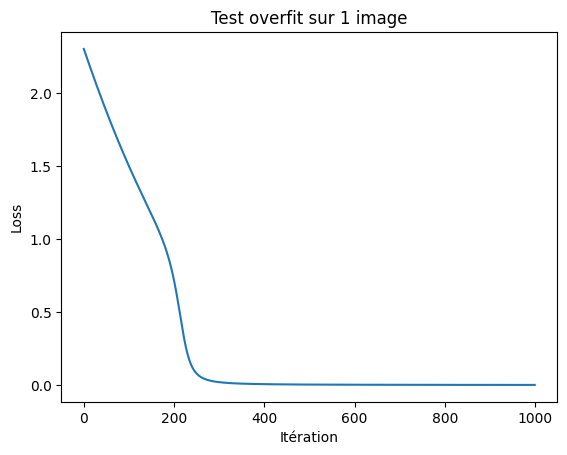

In [6]:
W_FCLayer3 = np.random.randn(128, 784) * 0.01
W_FCLayer2 = np.random.randn(64, 128) * 0.01
W_FCLayer1 = np.random.randn(10, 64) * 0.01
b_FCLayer3 = np.zeros((128, 1))
b_FCLayer2 = np.zeros((64, 1))
b_FCLayer1 = np.zeros((10, 1))

x = X_train[0].reshape(784, 1) / 255
y = y_train[0]
loss_overfit = []

for i in range(1000):
  FC3 = FullyConnectedLayer(W_FCLayer3, x, b_FCLayer3)
  ReLU2 = ReLULayer(FC3)
  FC2 = FullyConnectedLayer(W_FCLayer2, ReLU2, b_FCLayer2)
  ReLU1 = ReLULayer(FC2)
  FC1 = FullyConnectedLayer(W_FCLayer1, ReLU1, b_FCLayer1)
  y_pred = softmax(FC1)

  Gra1 = Gradient_1(y, y_pred)
  Gra2 = Gradient2(ReLU1, Gra1)
  Gra3 = Gradient3(FC2, Gra1, W_FCLayer1)
  Gra4 = Gradient4(ReLU2, Gra3)
  Gra5 = Gradient5(FC3, Gra3, W_FCLayer2)
  Gra6 = Gradient6(x, Gra5)

  W_FCLayer3 = maj_W(Gra6[0], W_FCLayer3, 0.01)
  b_FCLayer3 = maj_b(Gra6[1], b_FCLayer3, 0.01)
  W_FCLayer2 = maj_W(Gra4[0], W_FCLayer2, 0.01)
  b_FCLayer2 = maj_b(Gra4[1], b_FCLayer2, 0.01)
  W_FCLayer1 = maj_W(Gra2[0], W_FCLayer1, 0.01)
  b_FCLayer1 = maj_b(Gra2[1], b_FCLayer1, 0.01)

  loss_overfit.append(Loss(y_pred, y)[0])

plt.plot(loss_overfit)
plt.xlabel("Itération")
plt.ylabel("Loss")
plt.title("Test overfit sur 1 image")
plt.show()

# 1.5 Validation of the backpropagation (overfit test)
Before investigating further why the model doesn't seem to learn, I check whether my backpropagation is mathematically correct by testing if the model can overfit a single image repeated over 1000 iterations. If the gradients are computed correctly, the loss should drop rapidly toward 0. This is indeed what happens here, confirming that the bug lies elsewhere (most likely in training image-by-image, without mini-batching).